In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df_animais = pd.read_json('/home/ulisses/Estudos/Fast Track AI 2026/Checkpoint 01/dataset_monitoramento_fauna.json')

In [43]:
df_animais.head()

,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct
0,1,CAM01,2026-05-01 00:04:00,25,Ema,Ave,3,19.3 °C,81.5%
1,2,CAM08,2026-05-01 00:18:00,9,Rã-manteiga,Anfíbio,3,16.6 °C,88.8%
2,3,CAM08,2026-05-01 00:32:00,6,Tatu-canastra,Mamífero,1,16.5 °C,96.3%
3,4,CAM12,2026-05-01 00:37:00,13,Rã-manteiga,Anfíbio,2,19.2 °C,92.1%
4,5,CAM03,2026-05-01 00:39:00,25,Tamanduá-bandeira,Mamífero,1,20.5 °C,82.6%


In [44]:
# Desafio 01
# Qual é o número médio de indivíduos por registro de capivara? 
# A maior parte dos registros envolve indivíduos isolados ou grupos?

In [45]:
df_capivaras = df_animais[df_animais['especie'] == 'Capivara']

In [46]:
df_capivaras.head()

,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct
9,10,CAM12,2026-05-01 00:51:00,31,Capivara,Mamífero,6,20.8 °C,97.1%
22,23,CAM12,2026-05-01 03:06:00,37,Capivara,Mamífero,5,15.7 °C,98.6%
37,38,CAM09,2026-05-01 05:11:00,30,Capivara,Mamífero,11,18.3 °C,96.3%
45,46,CAM10,2026-05-01 06:04:00,4,Capivara,Mamífero,7,18.5 °C,88.0%
47,48,CAM12,2026-05-01 06:08:00,24,Capivara,Mamífero,3,17.7 °C,99.0%


In [47]:
df_capivaras.info()

<class 'pandas.core.frame.DataFrame'>
Index: 731 entries, 9 to 4995
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_registro       731 non-null    int64 
 1   id_camera         731 non-null    object
 2   data_hora_inicio  731 non-null    object
 3   duracao_segundos  731 non-null    int64 
 4   especie           731 non-null    object
 5   grupo             731 non-null    object
 6   individuos        731 non-null    int64 
 7   temperatura_c     709 non-null    object
 8   umidade_pct       699 non-null    object
dtypes: int64(3), object(6)
memory usage: 57.1+ KB


In [48]:
individual = df_capivaras[df_capivaras['individuos'] == 1].shape[0]
total = df_capivaras.shape[0]
percentual = (individual/total)*100

In [49]:
print(individual)
print(total)
print(percentual)

6
731
0.8207934336525308


In [50]:
media = df_capivaras['individuos'].mean()

In [51]:
print(media)

5.954856361149111


In [52]:
# Desafio 1 - Repsosta
# Aparições de capivaras individuais são menores que 1% dos registros. 
# Demonstrando que elas preferem andar em grupos, sendo a média apresentada de 
# aproximadamente 6 indivíduos por registro.

In [53]:
# Desafio 2
# Em quais períodos do dia há mais registros de animais? 
# Escolha três espécies e compare seus horários de maior ocorrência.

In [54]:
df_animais['data_hora_inicio'] = pd.to_datetime(df_animais['data_hora_inicio'])

In [55]:
horarios = [0, 5, 12, 17, 24]
periodos = ['Madrugada', 'Manhã', 'Tarde', 'Noite']

In [56]:
df_animais['periodo'] = pd.cut(df_animais['data_hora_inicio'].dt.hour, bins=horarios, labels=periodos, ordered=False, include_lowest=True)

In [57]:
df_animais.head()

,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct,periodo
0,1,CAM01,2026-05-01 00:04:00,25,Ema,Ave,3,19.3 °C,81.5%,Madrugada
1,2,CAM08,2026-05-01 00:18:00,9,Rã-manteiga,Anfíbio,3,16.6 °C,88.8%,Madrugada
2,3,CAM08,2026-05-01 00:32:00,6,Tatu-canastra,Mamífero,1,16.5 °C,96.3%,Madrugada
3,4,CAM12,2026-05-01 00:37:00,13,Rã-manteiga,Anfíbio,2,19.2 °C,92.1%,Madrugada
4,5,CAM03,2026-05-01 00:39:00,25,Tamanduá-bandeira,Mamífero,1,20.5 °C,82.6%,Madrugada


In [58]:
# Quantidade de indivíduos regsitrados por período.

In [59]:
qt_periodo = df_animais.groupby('periodo', observed = False)['individuos'].sum()


In [60]:
print(qt_periodo)

periodo
Madrugada    2648
Manhã        5094
Tarde        3754
Noite        2831
Name: individuos, dtype: int64


In [61]:
# Quantidade de registros por período independente da quantidade de indivíduos.

In [63]:
qt_periodo_obs = df_animais.groupby('periodo', observed = False)['individuos'].count()

In [64]:
print(qt_periodo_obs)

periodo
Madrugada    1087
Manhã        1600
Tarde        1136
Noite        1177
Name: individuos, dtype: int64


In [65]:
# Verificar as espécies observadas

In [66]:
print(df_animais.groupby('especie', observed = False)['individuos'].sum())

especie
Capivara             4353
Cervo-do-pantanal     378
Ema                  1969
Lobo-guará            532
Onça-pintada           27
Perereca-verde        915
Quati                1287
Rã-manteiga           823
Sapo-cururu          1268
Seriema              1247
Tamanduá-bandeira     495
Tatu-canastra         359
Veado-campeiro        674
Name: individuos, dtype: int64


In [67]:
especies_selec = ['Ema', 'Sapo-cururu', 'Seriema']

In [69]:
qt_periodo_selec = df_animais[df_animais['especie'].isin(especies_selec)].groupby(['especie','periodo'], observed = False)['individuos'].sum()

In [70]:
print(qt_periodo_selec)

especie      periodo  
Ema          Madrugada    187
             Manhã        883
             Tarde        696
             Noite        203
Sapo-cururu  Madrugada    559
             Manhã        143
             Tarde         97
             Noite        469
Seriema      Madrugada    158
             Manhã        578
             Tarde        400
             Noite        111
Name: individuos, dtype: int64


In [86]:
qt_periodo_especies = df_animais.groupby(['especie','periodo'], observed = False,as_index=False).agg( Qtd = ('individuos','sum'))

In [87]:
qt_periodo_especies.head()

,especie,periodo,Qtd
0,Capivara,Madrugada,437
1,Capivara,Manhã,1995
2,Capivara,Tarde,1427
3,Capivara,Noite,494
4,Cervo-do-pantanal,Madrugada,72


In [89]:
df_pivot = qt_periodo_especies.set_index(["especie", "periodo"])["Qtd"].unstack(fill_value=0)

In [94]:
df_pivot.head()

periodo,Madrugada,Manhã,Tarde,Noite
especie,,,,
Capivara,437,1995,1427,494
Cervo-do-pantanal,72,121,91,94
Ema,187,883,696,203
Lobo-guará,96,173,125,138
Onça-pintada,8,5,1,13


In [90]:
# Garantir a ordem cronológica dos períodos no gráfico
ordem_periodos = ["Madrugada", "Manhã", "Tarde", "Noite"]
df_pivot = df_pivot.reindex(columns=ordem_periodos, fill_value=0)

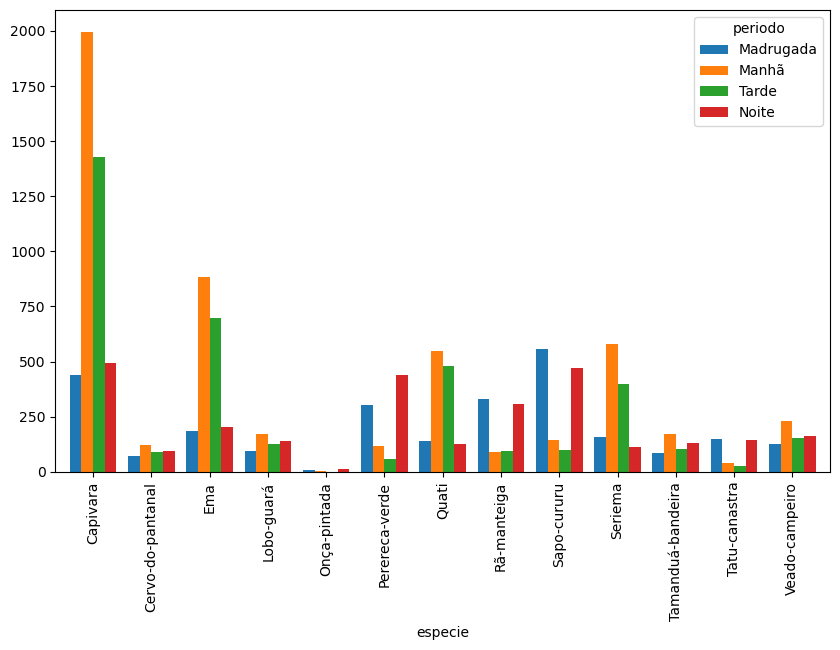

In [91]:
# Configurar e desenhar o gráfico de barras agrupadas
ax = df_pivot.plot(kind="bar", figsize=(10, 6), width=0.8)

In [ ]:
# Desafio 2 - Resultado
# De forma geral existem mais registros de animais pela manhã.
# Porém ao observar as espécies é possível notar que algumas espécies, 
# principalmente anfíbios tem mais registros a noite

In [ ]:
# Desafio 3
# Os anfíbios são registrados com maior frequência quando a umidade é mais alta? 
# Compare a quantidade de registros em diferentes níveis de umidade e apresente sua conclusão.

In [95]:
df_anfibios = df_animais[df_animais['grupo']=='Anfíbio']

In [96]:
df_anfibios.head()

,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct,periodo
1,2,CAM08,2026-05-01 00:18:00,9,Rã-manteiga,Anfíbio,3,16.6 °C,88.8%,Madrugada
3,4,CAM12,2026-05-01 00:37:00,13,Rã-manteiga,Anfíbio,2,19.2 °C,92.1%,Madrugada
5,6,CAM08,2026-05-01 00:47:00,19,Sapo-cururu,Anfíbio,3,18.2 °C,90.9%,Madrugada
7,8,CAM05,2026-05-01 00:49:00,35,Perereca-verde,Anfíbio,2,14.6 °C,94.1%,Madrugada
8,9,CAM04,2026-05-01 00:49:00,46,Sapo-cururu,Anfíbio,3,20.6 °C,92.8%,Madrugada


In [101]:
df_anf_umd = df_anfibios.groupby(['umidade_pct'], observed = False,as_index=False).agg( Qtd = ('individuos','sum'))

In [102]:
df_anf_umd.head()

,umidade_pct,Qtd
0,46.5%,2
1,51.0%,3
2,51.2%,2
3,53.3%,2
4,53.4%,4


In [107]:
df_anf_umd["umidade_pct_num"] = (
    df_anf_umd["umidade_pct"].str.replace("%", "").astype(float)
)

In [108]:
df_anf_umd = df_anf_umd.sort_values(by="umidade_pct_num")

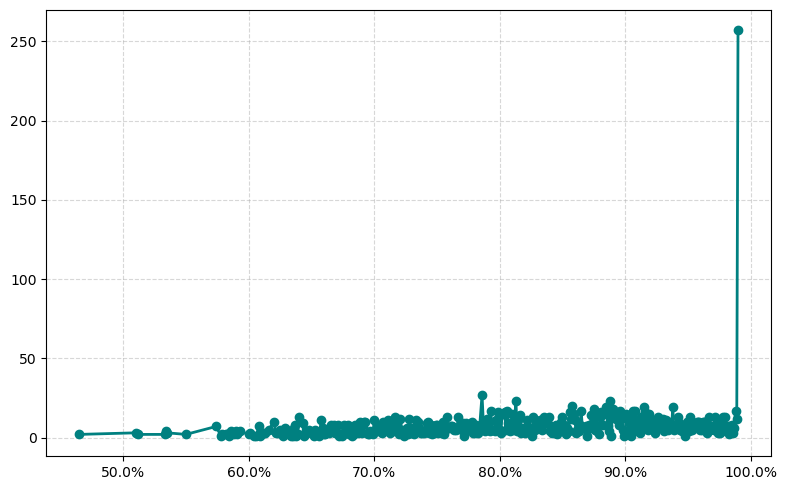

In [113]:
plt.figure(figsize=(8, 5))
plt.plot(
    df_anf_umd["umidade_pct_num"],
    df_anf_umd["Qtd"],
    marker="o",
    linestyle="-",
    color="teal",
    linewidth=2,
    label="Quantidade",
)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x}%"))

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Desafio 3 - Resposta:
# Conforme apresentado no gráfico é possível notar uam consistência na aparição de anfíbios em geral, 
# porém existem picos de registros quando próximo ao 100% de umidade.